In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os

parquet_files = ['/content/yellow_tripdata_2025-12.parquet', '/content/yellow_tripdata_2026-01.parquet', '/content/yellow_tripdata_2026-02.parquet']

combined_df = pd.concat([pd.read_parquet(file) for file in parquet_files], ignore_index=True)

output_csv = 'merged_output.csv'
combined_df.to_csv(output_csv, index=False)

print(f"Successfully merged {len(parquet_files)} files into {output_csv}")

Successfully merged 3 files into merged_output.csv


In [ ]:
from google.colab import drive
from google.colab import files

output_file = 'merged_output.csv'

# Load the merged CSV file into a pandas DataFrame
df = pd.read_csv(output_file)

# Display the first 5 rows of the DataFrame
display(df.head())

/tmp/ipykernel_1322/28909133.py:7: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(output_file)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-12-01 00:37:08,2025-12-01 00:51:10,1.0,2.40,1.0,N,140,48,1,14.2,4.25,0.5,4.00,0.00,1.0,23.95,2.5,0.00,0.75
1,2,2025-12-01 00:03:54,2025-12-01 00:19:18,1.0,8.37,1.0,N,138,262,1,33.1,6.00,0.5,7.77,6.94,1.0,59.56,2.5,1.75,0.00
2,2,2025-12-01 00:40:50,2025-12-01 01:06:54,1.0,15.26,1.0,N,132,255,1,57.6,1.00,0.5,12.02,0.00,1.0,73.87,0.0,1.75,0.00
3,1,2025-12-01 00:21:30,2025-12-01 00:49:35,2.0,18.40,2.0,N,132,79,1,70.0,5.00,0.5,10.00,0.00,1.0,86.50,2.5,1.75,0.75
4,2,2025-12-01 00:00:24,2025-12-01 00:03:34,1.0,0.52,1.0,N,239,238,1,5.8,1.00,0.5,1.62,0.00,1.0,12.42,2.5,0.00,0.00


In [ ]:
# Display basic information about the DataFrame
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11429761 entries, 0 to 11429760
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
 18  Airport_fee            float64
 19  cbd_congestion_fee     float64
dtypes: float64(13), int64(4), object(3)
memory usage: 1.7+ GB


None

From the `df.info()` output, we can see that `tpep_pickup_datetime` and `tpep_dropoff_datetime` are currently `object` type, which suggests they are strings. We need to convert them to datetime objects for proper time-series analysis. Also, `store_and_fwd_flag` is an `object` type, which is likely the cause of the `DtypeWarning` because it contains mixed types (e.g., 'Y', 'N', and potentially some other values that are not strings).

In [ ]:
# Convert datetime columns to datetime objects
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Investigate 'store_and_fwd_flag' column
print("Unique values in 'store_and_fwd_flag' before cleaning:")
print(df['store_and_fwd_flag'].unique())

# Convert 'store_and_fwd_flag' to categorical type. Fill NaN with mode if any.
# Assuming 'N' and 'Y' are the primary values, anything else might be an anomaly or missing.
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].astype(str).str.strip().replace({'nan': None})

# Fill NaN values with the mode 'N' if it is present
if 'N' in df['store_and_fwd_flag'].mode().values:
    df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna('N')
else:
    df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(df['store_and_fwd_flag'].mode()[0])


# Display data types after conversion
display(df.info())

print("Unique values in 'store_and_fwd_flag' after cleaning:")
print(df['store_and_fwd_flag'].unique())

Unique values in 'store_and_fwd_flag' before cleaning:
['N' 'Y' nan]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11429761 entries, 0 to 11429760
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       

None

Unique values in 'store_and_fwd_flag' after cleaning:
['N' 'Y']


In [ ]:
# Check unique values and missing values for 'passenger_count'
print("Unique values in 'passenger_count' before cleaning:")
print(df['passenger_count'].unique())
print("Number of NaN values in 'passenger_count':", df['passenger_count'].isnull().sum())

# Check unique values and missing values for 'RatecodeID'
print("\nUnique values in 'RatecodeID' before cleaning:")
print(df['RatecodeID'].unique())
print("Number of NaN values in 'RatecodeID':", df['RatecodeID'].isnull().sum())

# Check unique values and missing values for 'payment_type'
print("\nUnique values in 'payment_type' before cleaning:")
print(df['payment_type'].unique())
print("Number of NaN values in 'payment_type':", df['payment_type'].isnull().sum())

Unique values in 'passenger_count' before cleaning:
[ 1.  2.  5.  3.  4.  6.  0.  8.  7.  9. nan]
Number of NaN values in 'passenger_count': 3306857

Unique values in 'RatecodeID' before cleaning:
[ 1.  2.  4.  5.  3. 99.  6. nan]
Number of NaN values in 'RatecodeID': 3306857

Unique values in 'payment_type' before cleaning:
[1 2 4 3 0]
Number of NaN values in 'payment_type': 0


In [ ]:
# Clean 'passenger_count'
# Fill NaN values with the mode and convert to integer
mode_passenger_count = df['passenger_count'].mode()[0]
df['passenger_count'] = df['passenger_count'].fillna(mode_passenger_count).astype(int)

# Clean 'RatecodeID'
# Replace 99s and NaNs with the mode, then convert to integer
mode_ratecode_id = df['RatecodeID'].mode()[0]
df['RatecodeID'] = df['RatecodeID'].replace(99, mode_ratecode_id).fillna(mode_ratecode_id).astype(int)

# Convert 'payment_type' to categorical
df['payment_type'] = df['payment_type'].astype('category')

# Display data types after conversion and cleaning
display(df.info())

print("Unique values in 'passenger_count' after cleaning:")
print(df['passenger_count'].unique())

print("Unique values in 'RatecodeID' after cleaning:")
print(df['RatecodeID'].unique())

print("Unique values in 'payment_type' after cleaning:")
print(df['payment_type'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11429761 entries, 0 to 11429760
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        int64         
 4   trip_distance          float64       
 5   RatecodeID             int64         
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           category      
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee         

None

Unique values in 'passenger_count' after cleaning:
[1 2 5 3 4 6 0 8 7 9]
Unique values in 'RatecodeID' after cleaning:
[1 2 4 5 3 6]
Unique values in 'payment_type' after cleaning:
[1, 2, 4, 3, 0]
Categories (5, int64): [0, 1, 2, 3, 4]


In [ ]:
# Check for any remaining missing values across the entire DataFrame
missing_values = df.isnull().sum()
print("Missing values per column after cleaning:")
print(missing_values[missing_values > 0])

Missing values per column after cleaning:
congestion_surcharge    3306857
Airport_fee             3306857
dtype: int64


In [ ]:
# Fill NaN values in 'congestion_surcharge' and 'Airport_fee' with 0
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)
df['Airport_fee'] = df['Airport_fee'].fillna(0)

# Check for any remaining missing values across the entire DataFrame again
missing_values_after_handling = df.isnull().sum()
print("Missing values per column after handling 'congestion_surcharge' and 'Airport_fee':")
print(missing_values_after_handling[missing_values_after_handling > 0])

Missing values per column after handling 'congestion_surcharge' and 'Airport_fee':
Series([], dtype: int64)


In [ ]:
# Identify columns with negative values (re-run for clarity if needed, or use a predefined list)
negative_value_columns = [
    'fare_amount', 'extra', 'mta_tax', 'tip_amount',
    'tolls_amount', 'improvement_surcharge', 'total_amount',
    'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee'
]

# Replace negative values with 0 in the identified columns
for col in negative_value_columns:
    df[col] = df[col].apply(lambda x: max(x, 0))

print("Negative values replaced with 0 in fare-related columns.")

# Verify if any negative values remain
negative_values_found_after_cleaning = False
for column in negative_value_columns:
    if (df[column] < 0).any():
        print(f"Column '{column}' still contains negative values after cleaning.")
        negative_values_found_after_cleaning = True

if not negative_values_found_after_cleaning:
    print("Successfully removed all negative values in the specified columns.")

Negative values replaced with 0 in fare-related columns.
Successfully removed all negative values in the specified columns.


In [ ]:
# Calculate trip duration
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Check for trips where dropoff is before pickup
inconsistent_dates = df[df['trip_duration'] < 0]
if not inconsistent_dates.empty:
    print(f"Found {len(inconsistent_dates)} trips where dropoff datetime is before pickup datetime.")
    display(inconsistent_dates.head())
else:
    print("No trips found where dropoff datetime is before pickup datetime.")

# Check for trips with zero duration (pickup and dropoff at the same time)
zero_duration_trips = df[df['trip_duration'] == 0]
if not zero_duration_trips.empty:
    print(f"Found {len(zero_duration_trips)} trips with zero duration.")
    display(zero_duration_trips.head())
else:
    print("No trips found with zero duration.")

Found 5 trips where dropoff datetime is before pickup datetime.


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration
3175478,1,2025-12-03 09:01:43,2025-12-03 09:01:42,1,0.00,1,N,107,107,0,...,0.0,0.5,0.0,0.0,1.0,28.98,0.0,0.0,0.75,-0.016667
4097497,6,2025-12-23 17:14:44,2025-12-23 16:30:00,1,4.16,1,N,71,76,0,...,0.0,0.5,0.0,0.0,0.3,0.00,0.0,0.0,0.00,-44.733333
5770440,1,2026-01-17 19:30:00,2026-01-17 19:18:18,1,16.50,1,N,46,86,1,...,0.0,0.5,0.0,0.0,0.0,67.00,0.0,0.0,0.00,-11.700000
9911870,1,2026-02-22 09:30:00,2026-02-22 09:28:57,1,0.60,1,N,166,41,1,...,0.0,0.5,0.0,0.0,0.0,17.00,0.0,0.0,0.00,-1.050000
11311970,2,2026-02-26 04:10:10,2026-02-26 04:10:00,1,0.02,1,N,77,77,0,...,0.0,0.0,0.0,0.0,1.0,0.00,0.0,0.0,0.00,-0.166667


Found 143684 trips with zero duration.


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration
105,7,2025-12-01 00:08:50,2025-12-01 00:08:50,1,0.90,1,N,239,143,1,...,0.0,0.5,2.30,0.00,1.0,13.80,2.5,0.00,0.00,0.0
106,7,2025-12-01 00:35:17,2025-12-01 00:35:17,4,2.54,1,N,143,170,2,...,0.0,0.5,0.00,0.00,1.0,25.55,2.5,0.00,0.75,0.0
241,7,2025-12-01 00:57:33,2025-12-01 00:57:33,1,8.74,1,N,138,107,1,...,0.0,0.5,10.79,6.94,1.0,64.73,2.5,6.75,0.75,0.0
306,7,2025-12-01 00:10:13,2025-12-01 00:10:13,1,1.46,1,N,186,113,1,...,0.0,0.5,2.87,0.00,1.0,17.22,2.5,0.00,0.75,0.0
346,7,2025-12-01 00:35:34,2025-12-01 00:35:34,1,12.27,1,N,138,209,1,...,0.0,0.5,8.00,0.00,1.0,69.00,2.5,6.75,0.75,0.0


In [ ]:
# Remove trips with zero duration
original_rows = len(df)
df = df[df['trip_duration'] != 0]
print(f"Removed {original_rows - len(df)} trips with zero duration.")
print(f"New number of rows: {len(df)}")

Removed 143684 trips with zero duration.
New number of rows: 11286077


In [ ]:
# Remove trips where dropoff datetime is before pickup datetime (trip_duration < 0)
original_rows_after_zero_duration_removal = len(df)
df = df[df['trip_duration'] >= 0]
print(f"Removed {original_rows_after_zero_duration_removal - len(df)} trips with inconsistent dates.")
print(f"New number of rows: {len(df)}")

Removed 5 trips with inconsistent dates.
New number of rows: 11286072


In [ ]:
# Verify if any trips with negative duration remain
inconsistent_dates_after_cleaning = df[df['trip_duration'] < 0]
if not inconsistent_dates_after_cleaning.empty:
    print(f"Found {len(inconsistent_dates_after_cleaning)} trips where dropoff datetime is before pickup datetime after cleaning.")
    display(inconsistent_dates_after_cleaning.head())
else:
    print("No trips found where dropoff datetime is before pickup datetime after cleaning. All such records have been successfully removed.")

No trips found where dropoff datetime is before pickup datetime after cleaning. All such records have been successfully removed.


In [ ]:
# Identify trips with a duration less than one minute (but greater than 0)
short_duration_trips = df[(df['trip_duration'] > 0) & (df['trip_duration'] < 1)]

if not short_duration_trips.empty:
    print(f"Found {len(short_duration_trips)} trips with a duration less than one minute.")
    display(short_duration_trips.head())
else:
    print("No trips found with a duration less than one minute.")

Found 118797 trips with a duration less than one minute.


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration
46,2,2025-12-01 00:07:23,2025-12-01 00:07:58,1,0.04,1,N,132,132,4,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.583333
47,2,2025-12-01 00:07:23,2025-12-01 00:07:58,1,0.04,1,N,132,132,4,...,1.0,0.5,0.0,0.0,1.0,7.25,0.0,1.75,0.00,0.583333
95,1,2025-12-01 00:33:11,2025-12-01 00:33:28,1,0.00,1,N,74,74,1,...,1.0,0.5,3.0,0.0,1.0,8.50,0.0,0.00,0.00,0.283333
243,2,2025-12-01 00:03:47,2025-12-01 00:03:52,1,0.00,1,N,48,50,1,...,1.0,0.5,5.0,0.0,1.0,13.75,2.5,0.00,0.75,0.083333
364,2,2025-12-01 00:19:21,2025-12-01 00:19:38,1,0.00,1,N,90,90,2,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.283333


In [ ]:
# Remove trips with duration less than one minute
original_rows_before_short_trip_removal = len(df)
df = df[df['trip_duration'] >= 1]
print(f"Removed {original_rows_before_short_trip_removal - len(df)} trips with duration less than one minute.")
print(f"New number of rows: {len(df)}")

Removed 118797 trips with duration less than one minute.
New number of rows: 11167275


In [ ]:
# Display descriptive statistics for numerical columns to identify potential outliers
display(df.describe())

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration
count,1.116728e+07,11167275,11167275,1.116728e+07,1.116728e+07,1.116728e+07,1.116728e+07,1.116728e+07,1.116728e+07,1.116728e+07,1.116728e+07,1.116728e+07,1.116728e+07,1.116728e+07,1.116728e+07,1.116728e+07,1.116728e+07,1.116728e+07,1.116728e+07
mean,1.812327e+00,2026-01-13 05:40:59.680051712,2026-01-13 05:59:27.787184640,1.189233e+00,6.696598e+00,1.053097e+00,1.613979e+02,1.609147e+02,2.175457e+01,1.066550e+00,4.909598e-01,2.671172e+00,5.126751e-01,9.604429e-01,3.032109e+01,1.553521e+00,1.048944e-01,5.310896e-01,1.846845e+01
min,1.000000e+00,2025-11-30 20:48:56,2025-11-30 20:57:48,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,2.000000e+00,2025-12-18 22:00:47.500000,2025-12-18 22:19:24,1.000000e+00,1.010000e+00,1.000000e+00,1.140000e+02,1.070000e+02,1.000000e+01,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.755000e+01,0.000000e+00,0.000000e+00,0.000000e+00,8.716667e+00
50%,2.000000e+00,2026-01-13 15:55:55,2026-01-13 16:14:32,1.000000e+00,1.830000e+00,1.000000e+00,1.610000e+02,1.620000e+02,1.630000e+01,0.000000e+00,5.000000e-01,2.000000e+00,0.000000e+00,1.000000e+00,2.394000e+01,2.500000e+00,0.000000e+00,7.500000e-01,1.430000e+01
75%,2.000000e+00,2026-02-05 14:08:56.500000,2026-02-05 14:32:25,1.000000e+00,3.800000e+00,1.000000e+00,2.330000e+02,2.340000e+02,2.750000e+01,2.500000e+00,5.000000e-01,3.850000e+00,0.000000e+00,1.000000e+00,3.528000e+01,2.500000e+00,0.000000e+00,7.500000e-01,2.271667e+01
max,6.000000e+00,2026-03-01 00:51:48,2026-03-01 23:11:29,9.000000e+00,3.285222e+05,6.000000e+00,2.650000e+02,2.650000e+02,2.555200e+03,2.071000e+01,9.600000e+01,8.000000e+02,1.222200e+02,1.000000e+00,2.560200e+03,2.500000e+00,5.000000e+00,7.500000e-01,9.265150e+03
std,4.215797e-01,NaN,NaN,5.896247e-01,6.794558e+02,3.549901e-01,6.698537e+01,7.097459e+01,1.780649e+01,1.714237e+00,7.273602e-02,3.866587e+00,2.107384e+00,1.942436e-01,2.139164e+01,1.212590e+00,4.154081e-01,3.409707e-01,2.589995e+01


In [ ]:
# Check quantiles for trip_distance to identify a reasonable upper bound
print("Quantiles for trip_distance:")
print(df['trip_distance'].quantile([0.99, 0.995, 0.999, 1.0]))

# Check quantiles for trip_duration to identify a reasonable upper bound
print("\nQuantiles for trip_duration:")
print(df['trip_duration'].quantile([0.99, 0.995, 0.999, 1.0]))

# Investigate mta_tax further
print("\nUnique values and counts for mta_tax:")
print(df['mta_tax'].value_counts().sort_index())

Quantiles for trip_distance:
0.990        19.55
0.995        21.59
0.999        30.14
1.000    328522.20
Name: trip_distance, dtype: float64

Quantiles for trip_duration:
0.990      75.816667
0.995      89.333333
0.999     127.850000
1.000    9265.150000
Name: trip_duration, dtype: float64

Unique values and counts for mta_tax:
mta_tax
0.00       202271
0.50     10964977
1.05            1
1.75            1
2.25            1
3.00            1
3.25            3
3.75            8
4.00            2
4.75            9
96.00           1
Name: count, dtype: int64


In [ ]:
# Cap trip_distance and trip_duration at their 99.9th percentiles
df['trip_distance'] = df['trip_distance'].clip(upper=df['trip_distance'].quantile(0.999))
df['trip_duration'] = df['trip_duration'].clip(upper=df['trip_duration'].quantile(0.999))

# Cap mta_tax at 0.50 for values greater than 0.50
df.loc[df['mta_tax'] > 0.50, 'mta_tax'] = 0.50

print("Outlier values in trip_distance, trip_duration, and mta_tax have been capped.")

# Verify the changes by re-checking quantiles and unique values
print("\nQuantiles for trip_distance after capping:")
print(df['trip_distance'].quantile([0.99, 0.995, 0.999, 1.0]))

print("\nQuantiles for trip_duration after capping:")
print(df['trip_duration'].quantile([0.99, 0.995, 0.999, 1.0]))

print("\nUnique values and counts for mta_tax after capping:")
print(df['mta_tax'].value_counts().sort_index())

Outlier values in trip_distance, trip_duration, and mta_tax have been capped.

Quantiles for trip_distance after capping:
0.990    19.55
0.995    21.59
0.999    30.14
1.000    30.14
Name: trip_distance, dtype: float64

Quantiles for trip_duration after capping:
0.990     75.816667
0.995     89.333333
0.999    127.850000
1.000    127.850000
Name: trip_duration, dtype: float64

Unique values and counts for mta_tax after capping:
mta_tax
0.0      202271
0.5    10965004
Name: count, dtype: int64


In [ ]:
# Check for duplicate records
duplicate_rows = df.duplicated().sum()

if duplicate_rows > 0:
    print(f"Found {duplicate_rows} duplicate rows in the DataFrame.")
    # Optionally, display some of the duplicate rows
    # display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head())
else:
    print("No duplicate rows found in the DataFrame.")

No duplicate rows found in the DataFrame.


In [ ]:
# Check for any remaining missing values across the entire DataFrame
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

Missing values per column:
Series([], dtype: int64)


In [ ]:
# Investigate 'passenger_count' for suspicious values, particularly 0
zero_passenger_trips = df[df['passenger_count'] == 0]

if not zero_passenger_trips.empty:
    print(f"Found {len(zero_passenger_trips)} trips with 0 passengers.")
    display(zero_passenger_trips.head())
else:
    print("No trips found with 0 passengers.")

# Also check the distribution of passenger_count for other anomalies
print("\nValue counts for 'passenger_count':")
print(df['passenger_count'].value_counts().sort_index())

Found 44850 trips with 0 passengers.


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration
357,1,2025-12-01 00:55:22,2025-12-01 01:22:10,0,18.5,1,N,132,25,1,...,2.75,0.5,10.0,0.00,1.0,83.05,0.0,1.75,0.00,26.800000
410,1,2025-12-01 00:06:17,2025-12-01 00:14:48,0,1.6,1,N,249,148,1,...,4.25,0.5,2.0,0.00,1.0,18.45,2.5,0.00,0.75,8.516667
607,1,2025-12-01 00:21:01,2025-12-01 00:45:29,0,8.5,1,N,249,264,1,...,4.25,0.5,0.0,6.94,1.0,49.99,2.5,0.00,0.75,24.466667
973,1,2025-12-01 00:55:18,2025-12-01 01:22:48,0,13.0,1,N,132,71,4,...,2.75,0.5,0.0,0.00,1.0,55.55,0.0,1.75,0.00,27.500000
1778,1,2025-12-01 01:53:28,2025-12-01 01:57:24,0,0.9,1,N,170,230,1,...,4.25,0.5,5.0,0.00,1.0,17.95,2.5,0.00,0.75,3.933333



Value counts for 'passenger_count':
passenger_count
0      44850
1    9668808
2    1012623
3     234524
4     164266
5      27437
6      14760
7          3
8          3
9          1
Name: count, dtype: int64


In [ ]:
# Remove trips with 0 passengers
original_rows_before_zero_passenger_removal = len(df)
df = df[df['passenger_count'] > 0]
print(f"Removed {original_rows_before_zero_passenger_removal - len(df)} trips with 0 passengers.")
print(f"New number of rows: {len(df)}")

# Verify the passenger_count distribution after removal
print("\nValue counts for 'passenger_count' after removal:")
print(df['passenger_count'].value_counts().sort_index())

Removed 44850 trips with 0 passengers.
New number of rows: 11122425

Value counts for 'passenger_count' after removal:
passenger_count
1    9668808
2    1012623
3     234524
4     164266
5      27437
6      14760
7          3
8          3
9          1
Name: count, dtype: int64


In [ ]:
# Extract temporal features
df['hour'] = df['tpep_pickup_datetime'].dt.hour
df['day'] = df['tpep_pickup_datetime'].dt.day_name()
df['month'] = df['tpep_pickup_datetime'].dt.month

# Display the first few rows with new features
display(df[['tpep_pickup_datetime', 'trip_duration', 'hour', 'day', 'month']].head())

,tpep_pickup_datetime,trip_duration,hour,day,month
0,2025-12-01 00:37:08,14.033333,0,Monday,12
1,2025-12-01 00:03:54,15.400000,0,Monday,12
2,2025-12-01 00:40:50,26.066667,0,Monday,12
3,2025-12-01 00:21:30,28.083333,0,Monday,12
4,2025-12-01 00:00:24,3.166667,0,Monday,12


## Exploratory Data Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display descriptive statistics for numerical columns
print("Descriptive Statistics for Numerical Columns:")
display(df.describe())

Descriptive Statistics for Numerical Columns:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,fare_amount,extra,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration,hour,month
count,1.112242e+07,11122425,11122425,1.112242e+07,1.112242e+07,1.112242e+07,1.112242e+07,1.112242e+07,1.112242e+07,1.112242e+07,...,1.112242e+07,1.112242e+07,1.112242e+07,1.112242e+07,1.112242e+07,1.112242e+07,1.112242e+07,1.112242e+07,1.112242e+07,1.112242e+07
mean,1.815157e+00,2026-01-13 05:52:05.885834240,2026-01-13 06:10:34.880506624,1.194028e+00,3.404412e+00,1.053043e+00,1.613606e+02,1.608800e+02,2.177526e+01,1.057063e+00,...,2.668789e+00,5.134421e-01,9.602908e-01,3.034076e+01,1.550320e+00,1.050718e-01,5.310444e-01,1.814149e+01,1.420119e+01,5.433571e+00
min,1.000000e+00,2025-11-30 20:48:56,2025-11-30 20:57:48,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00
25%,2.000000e+00,2025-12-18 22:10:15,2025-12-18 22:28:28,1.000000e+00,1.020000e+00,1.000000e+00,1.140000e+02,1.070000e+02,1.000000e+01,0.000000e+00,...,0.000000e+00,0.000000e+00,1.000000e+00,1.755000e+01,0.000000e+00,0.000000e+00,0.000000e+00,8.733333e+00,1.000000e+01,1.000000e+00
50%,2.000000e+00,2026-01-13 16:04:40,2026-01-13 16:23:42,1.000000e+00,1.840000e+00,1.000000e+00,1.610000e+02,1.620000e+02,1.630000e+01,0.000000e+00,...,2.000000e+00,0.000000e+00,1.000000e+00,2.394000e+01,2.500000e+00,0.000000e+00,7.500000e-01,1.430000e+01,1.500000e+01,2.000000e+00
75%,2.000000e+00,2026-02-05 14:17:10,2026-02-05 14:41:07,1.000000e+00,3.800000e+00,1.000000e+00,2.330000e+02,2.340000e+02,2.750000e+01,2.500000e+00,...,3.850000e+00,0.000000e+00,1.000000e+00,3.534000e+01,2.500000e+00,0.000000e+00,7.500000e-01,2.273333e+01,1.900000e+01,1.200000e+01
max,6.000000e+00,2026-03-01 00:51:48,2026-03-01 23:11:29,9.000000e+00,3.014000e+01,6.000000e+00,2.650000e+02,2.650000e+02,2.555200e+03,2.071000e+01,...,8.000000e+02,1.222200e+02,1.000000e+00,2.560200e+03,2.500000e+00,5.000000e+00,7.500000e-01,1.278500e+02,2.300000e+01,1.200000e+01
std,4.195898e-01,NaN,NaN,5.859465e-01,4.194552e+00,3.547686e-01,6.699258e+01,7.098165e+01,1.781619e+01,1.707535e+00,...,3.867963e+00,2.108602e+00,1.946011e-01,2.140177e+01,1.213387e+00,4.157368e-01,3.409914e-01,1.457499e+01,5.997958e+00,5.112068e+00


### Distribution of Key Numerical Features

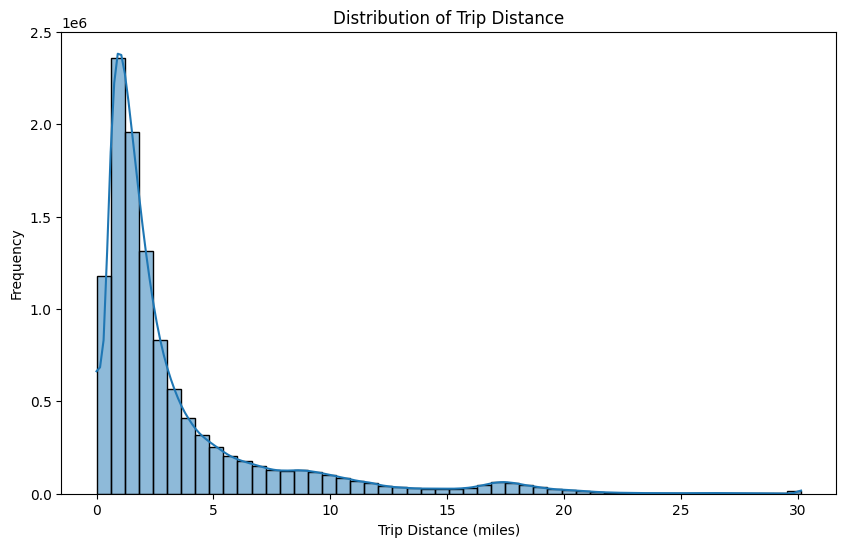

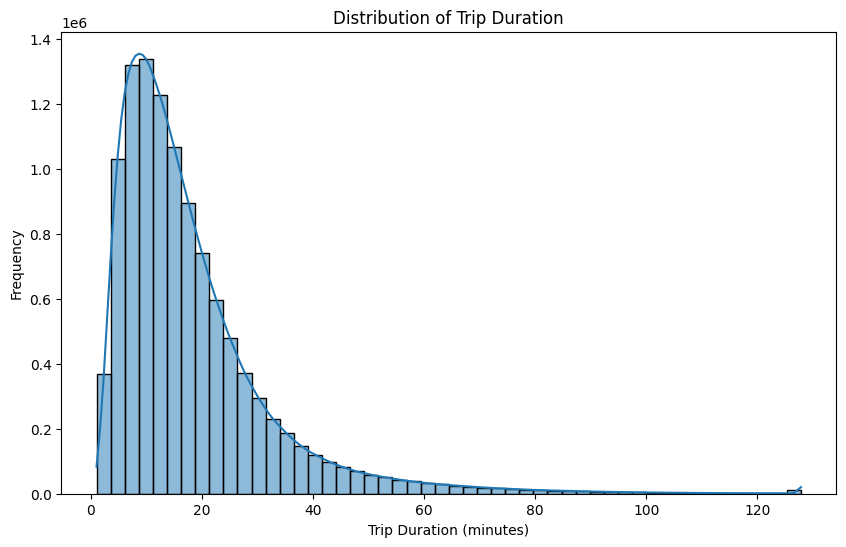

In [ ]:
# Distribution of Trip Distance
plt.figure(figsize=(10, 6))
sns.histplot(df['trip_distance'], bins=50, kde=True)
plt.title('Distribution of Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Frequency')
plt.show()

# Distribution of Trip Duration
plt.figure(figsize=(10, 6))
sns.histplot(df['trip_duration'], bins=50, kde=True)
plt.title('Distribution of Trip Duration')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
display(df.head())

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration,hour,day,month
0,1,2025-12-01 00:37:08,2025-12-01 00:51:10,1,2.40,1,N,140,48,1,...,0.00,1.0,23.95,2.5,0.00,0.75,14.033333,0,Monday,12
1,2,2025-12-01 00:03:54,2025-12-01 00:19:18,1,8.37,1,N,138,262,1,...,6.94,1.0,59.56,2.5,1.75,0.00,15.400000,0,Monday,12
2,2,2025-12-01 00:40:50,2025-12-01 01:06:54,1,15.26,1,N,132,255,1,...,0.00,1.0,73.87,0.0,1.75,0.00,26.066667,0,Monday,12
3,1,2025-12-01 00:21:30,2025-12-01 00:49:35,2,18.40,2,N,132,79,1,...,0.00,1.0,86.50,2.5,1.75,0.75,28.083333,0,Monday,12
4,2,2025-12-01 00:00:24,2025-12-01 00:03:34,1,0.52,1,N,239,238,1,...,0.00,1.0,12.42,2.5,0.00,0.00,3.166667,0,Monday,12


### Distribution of Categorical/Temporal Features

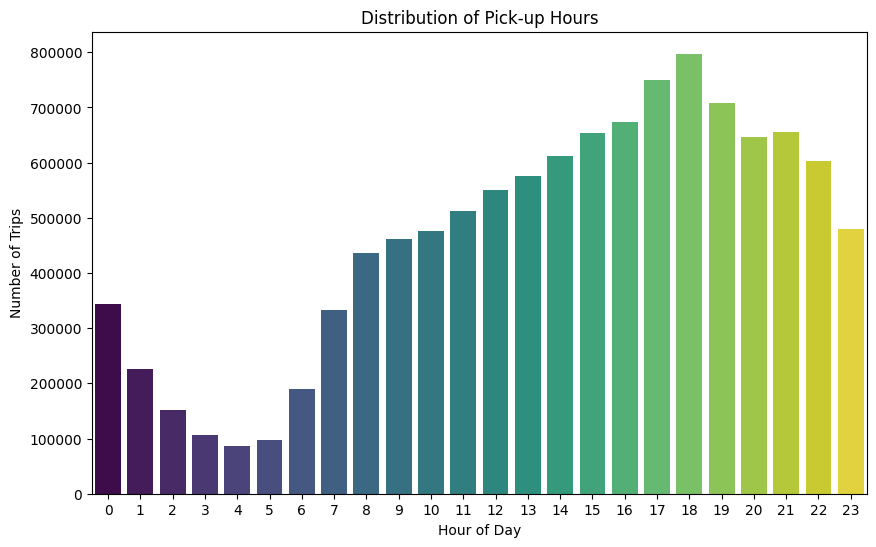

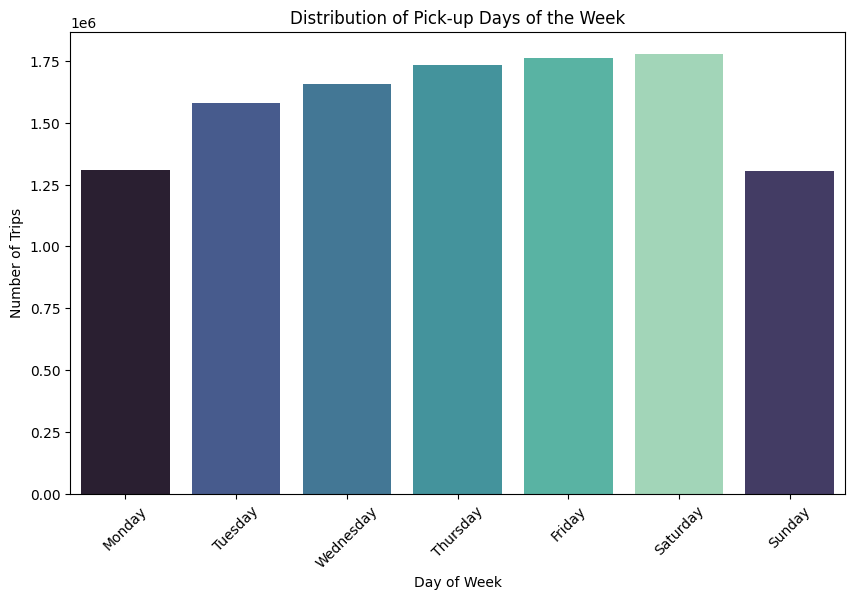

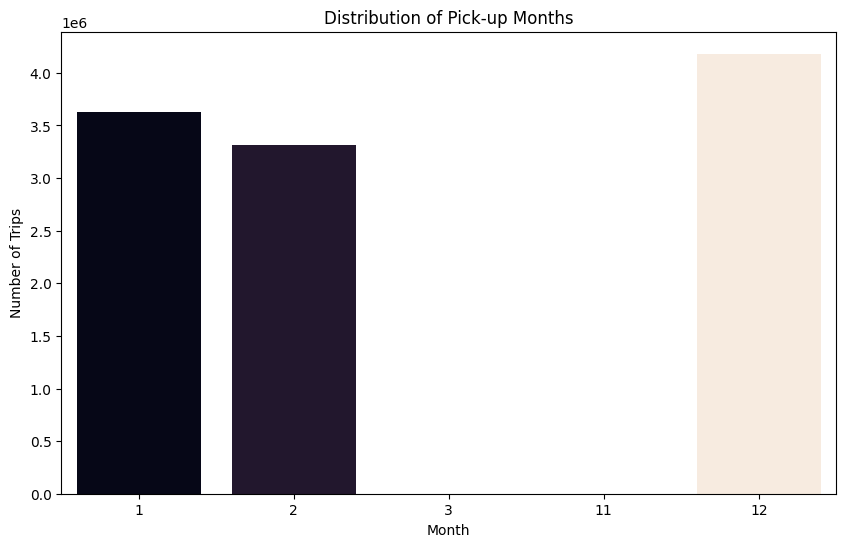

In [ ]:
# Distribution of Pick-up Hours
plt.figure(figsize=(10, 6))
sns.countplot(x='hour', data=df, palette='viridis', hue='hour', legend=False)
plt.title('Distribution of Pick-up Hours')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.show()

# Distribution of Pick-up Days
plt.figure(figsize=(10, 6))
sns.countplot(x='day', data=df, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='mako', hue='day', legend=False)
plt.title('Distribution of Pick-up Days of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.show()

# Distribution of Pick-up Months
plt.figure(figsize=(10, 6))
sns.countplot(x='month', data=df, palette='rocket', hue='month', legend=False)
plt.title('Distribution of Pick-up Months')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.show()

### Correlation Matrix of Numerical Features

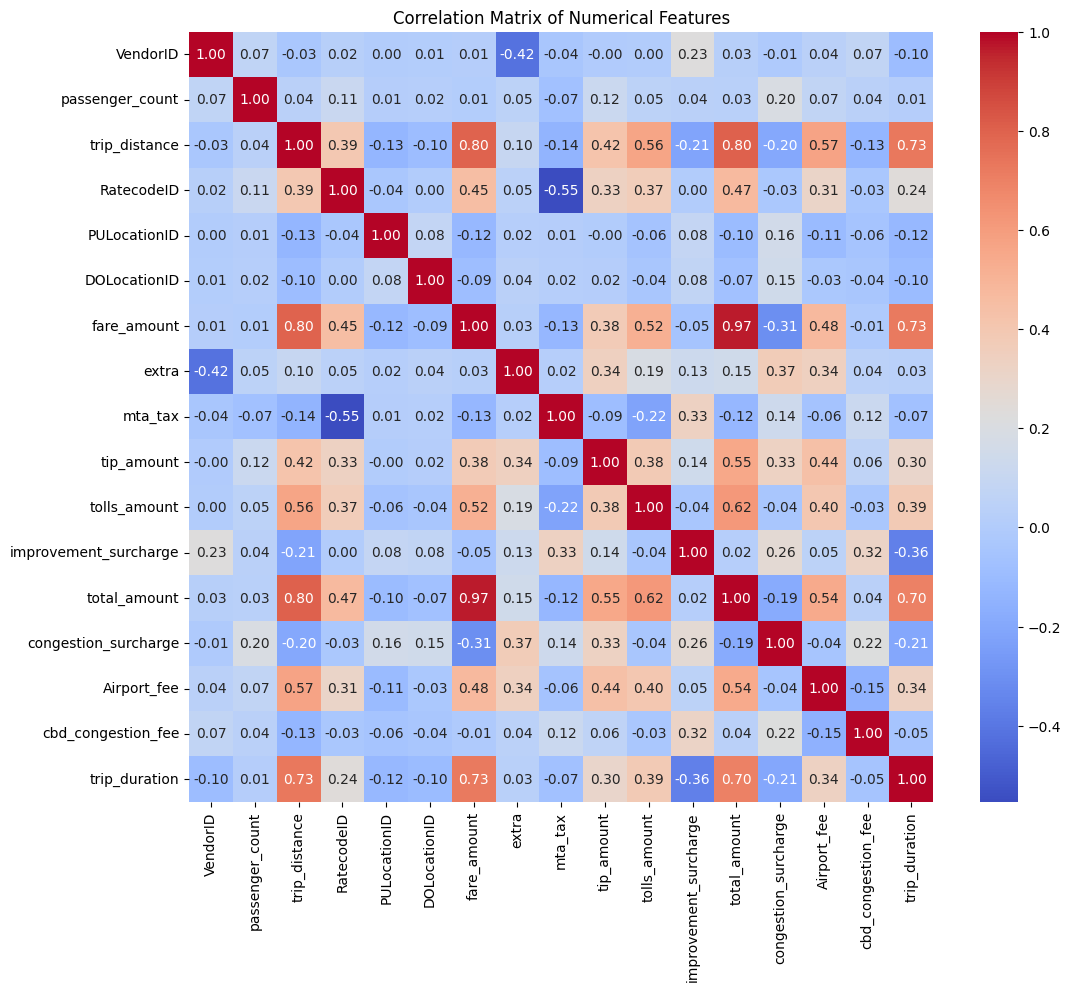

In [ ]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Data Mining - Clustering

### Feature Selection and Scaling for Clustering

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select numerical features relevant for clustering
# Exclude 'VendorID', 'PULocationID', 'DOLocationID' if they are treated as categorical later, or include if their numerical value is meaningful.
# For now, let's select a few key numerical features and trip-related features.
features_for_clustering = [
    'passenger_count',
    'trip_distance',
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'total_amount',
    'congestion_surcharge',
    'Airport_fee',
    'cbd_congestion_fee',
    'trip_duration',
    'hour',
    'month'
]

X = df[features_for_clustering]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features selected and scaled for clustering.")

Features selected and scaled for clustering.


### Determining Optimal Number of Clusters (Elbow Method)

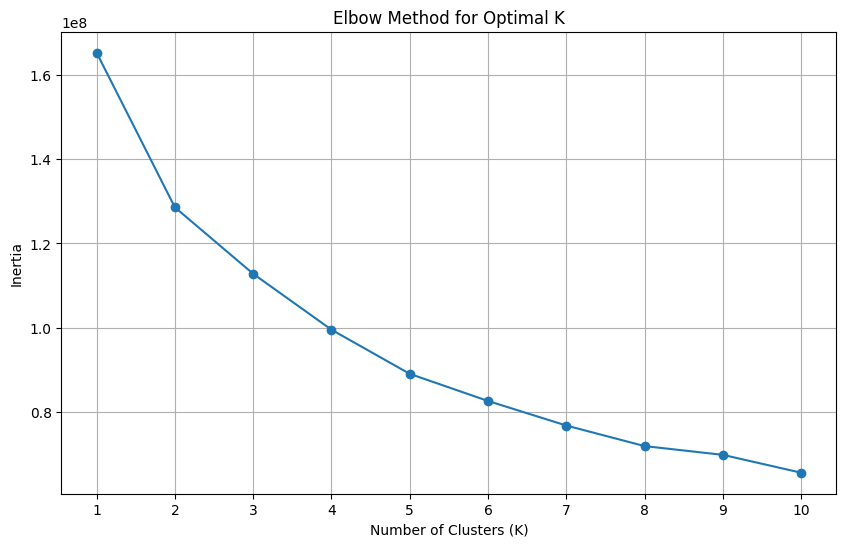

Elbow method plot generated to help determine the optimal number of clusters.


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Initialize a list to store inertia values
inertia = []

# Define a range of cluster numbers to try
# Using a smaller range for faster computation on large datasets
k_range = range(1, 11) # Try 1 to 10 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init to suppress warning
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

print("Elbow method plot generated to help determine the optimal number of clusters.")

### Applying K-Means Clustering

In [ ]:
# Apply K-Means clustering with 3 clusters
k_optimal = 3 # Based on typical elbow points or user input
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means clustering applied with {k_optimal} clusters.")

# Display the distribution of clusters
print("\nDistribution of observations per cluster:")
print(df['cluster'].value_counts().sort_index())

K-Means clustering applied with 3 clusters.

Distribution of observations per cluster:
cluster
0    6375534
1    3796003
2     844482
Name: count, dtype: int64


### Visualizing Cluster Characteristics

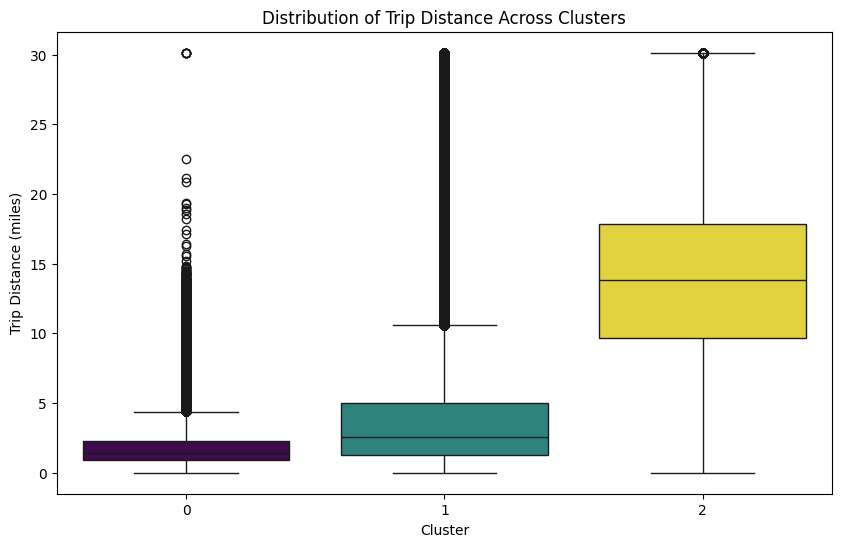

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='trip_distance', data=df, palette='viridis', hue='cluster', legend=False)
plt.title('Distribution of Trip Distance Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Trip Distance (miles)')
plt.show()

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='trip_distance', y='trip_duration', hue='cluster', data=df, palette='viridis', alpha=0.6)
plt.title('Trip Distance vs. Trip Duration by Cluster')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Trip Duration (minutes)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()